# Exploratory analysis of `noisy_ensemble.py`'s output

In [2]:
from pathlib import Path

import xarray as xr
import matplotlib.pyplot as plt
import matplotlib.animation as animation
import numpy as np
import cmocean as cm
import cartopy.crs as ccrs
import cartopy.feature as cfeature

In [3]:
landmask_path = Path("../Landmasks/Landmask.zarr")
landmask = xr.open_dataarray(landmask_path)
ocean_mask = ~landmask

/Odyssey/private/g22cossi/.miniforge3/envs/samudra/lib/python3.10/site-packages/xarray/backends/plugins.py:159: RuntimeWarning: 'scipy' fails while guessing
  warnings.warn(f"{engine!r} fails while guessing", RuntimeWarning)


## Quick look at a single member

In [ ]:
rollout_dir = Path("../Rollouts/Gaussian-25_member/ENS_OM4_thermo-sigma_2.0")

member_id = 24
member_ds = xr.open_dataset(rollout_dir / str(member_id).zfill(2) / "predictions.zarr", chunks=dict(time=1)) * ocean_mask.where(ocean_mask)
member_ds

/Odyssey/private/g22cossi/.miniforge3/envs/samudra/lib/python3.10/site-packages/xarray/backends/plugins.py:159: RuntimeWarning: 'scipy' fails while guessing
  warnings.warn(f"{engine!r} fails while guessing", RuntimeWarning)


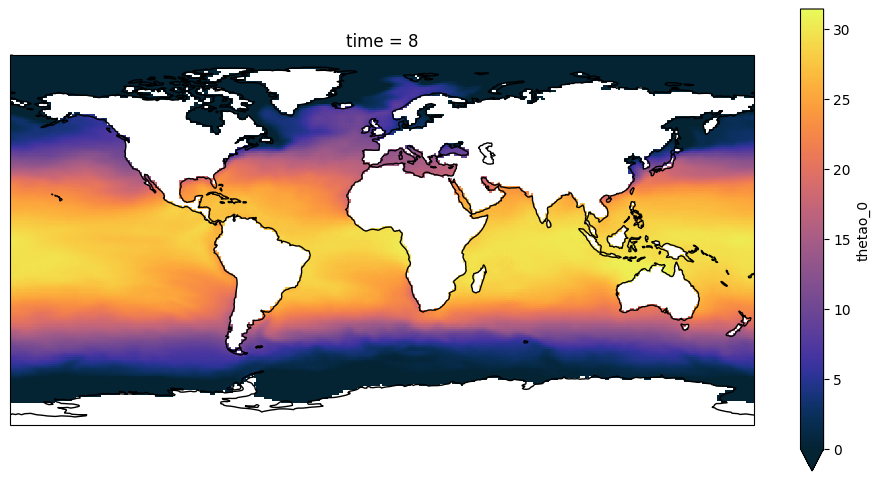

In [ ]:
fig = plt.figure(figsize=(12,6))
ax = plt.axes(projection=ccrs.PlateCarree())

timestep = 300

member_ds.isel(time=timestep)["thetao_0"].plot(
    ax=ax,
    transform=ccrs.PlateCarree(),
    cmap=cm.cm.thermal,
    vmin=0
)

ax.coastlines()

## Understanding the data files

The Samudra repo contains links to the preprocessed OM4 data needed for rollouts and
"means" and "stds" files

In [ ]:
means_path = Path("/Odyssey/public/Samudra/OM4_means.zarr")
stds_path = Path("/Odyssey/public/Samudra/OM4_stds.zarr")

ds = xr.open_dataset(means_path)
ds.thetao_lev_10_0

/Odyssey/private/g22cossi/.miniforge3/envs/samudra/lib/python3.10/site-packages/xarray/backends/plugins.py:159: RuntimeWarning: 'scipy' fails while guessing
  warnings.warn(f"{engine!r} fails while guessing", RuntimeWarning)


<xarray.DataArray 'thetao_lev_10_0' ()>
[1 values with dtype=float32]

These files don't contain exactly the format we want. There is a function in `utils.data` called `validate_data` which reformats the input `xr.Dataset` to the format expected by Samudra.

## Analyzing noisy ensemble members at different noise levels

**05/01/2026:** here we analyze the output of the `run_ensemble_test.sh` script.

### Individual run analysis

In [ ]:
noise_level = 1.0 # 0.1, 0.2, 0.5, 1.0
member_id = 1

rollout_dir = Path(f"../Rollouts/Gaussian-25_member/ENS_OM4_thermo-sigma_{noise_level}")

member_ds = xr.open_dataset(rollout_dir / str(member_id).zfill(2) / "predictions.zarr")
member_ds

/Odyssey/private/g22cossi/.miniforge3/envs/samudra/lib/python3.10/site-packages/xarray/backends/plugins.py:159: RuntimeWarning: 'scipy' fails while guessing
  warnings.warn(f"{engine!r} fails while guessing", RuntimeWarning)


<xarray.Dataset>
Dimensions:    (lat: 180, lon: 360, time: 362)
Coordinates:
    areacello  (lat, lon) float64 ...
  * lat        (lat) float64 -89.24 -88.25 -87.25 -86.26 ... 87.25 88.25 89.24
  * lon        (lon) float64 0.5 1.5 2.5 3.5 4.5 ... 356.5 357.5 358.5 359.5
  * time       (time) int64 0 1 2 3 4 5 6 7 8 9 ... 61 62 63 64 65 66 67 68 69
Data variables: (12/39)
    so_0       (time, lat, lon) float32 ...
    so_1       (time, lat, lon) float32 ...
    so_10      (time, lat, lon) float32 ...
    so_11      (time, lat, lon) float32 ...
    so_12      (time, lat, lon) float32 ...
    so_13      (time, lat, lon) float32 ...
    ...         ...
    thetao_5   (time, lat, lon) float32 ...
    thetao_6   (time, lat, lon) float32 ...
    thetao_7   (time, lat, lon) float32 ...
    thetao_8   (time, lat, lon) float32 ...
    thetao_9   (time, lat, lon) float32 ...
    zos        (time, lat, lon) float32 ...
Attributes:
    model_path:  /Odyssey/private/g22cossi/Samudra/Checkpoints/samudra_thermo...

Text(0.5, 0.98, 'sigma = 1.0')

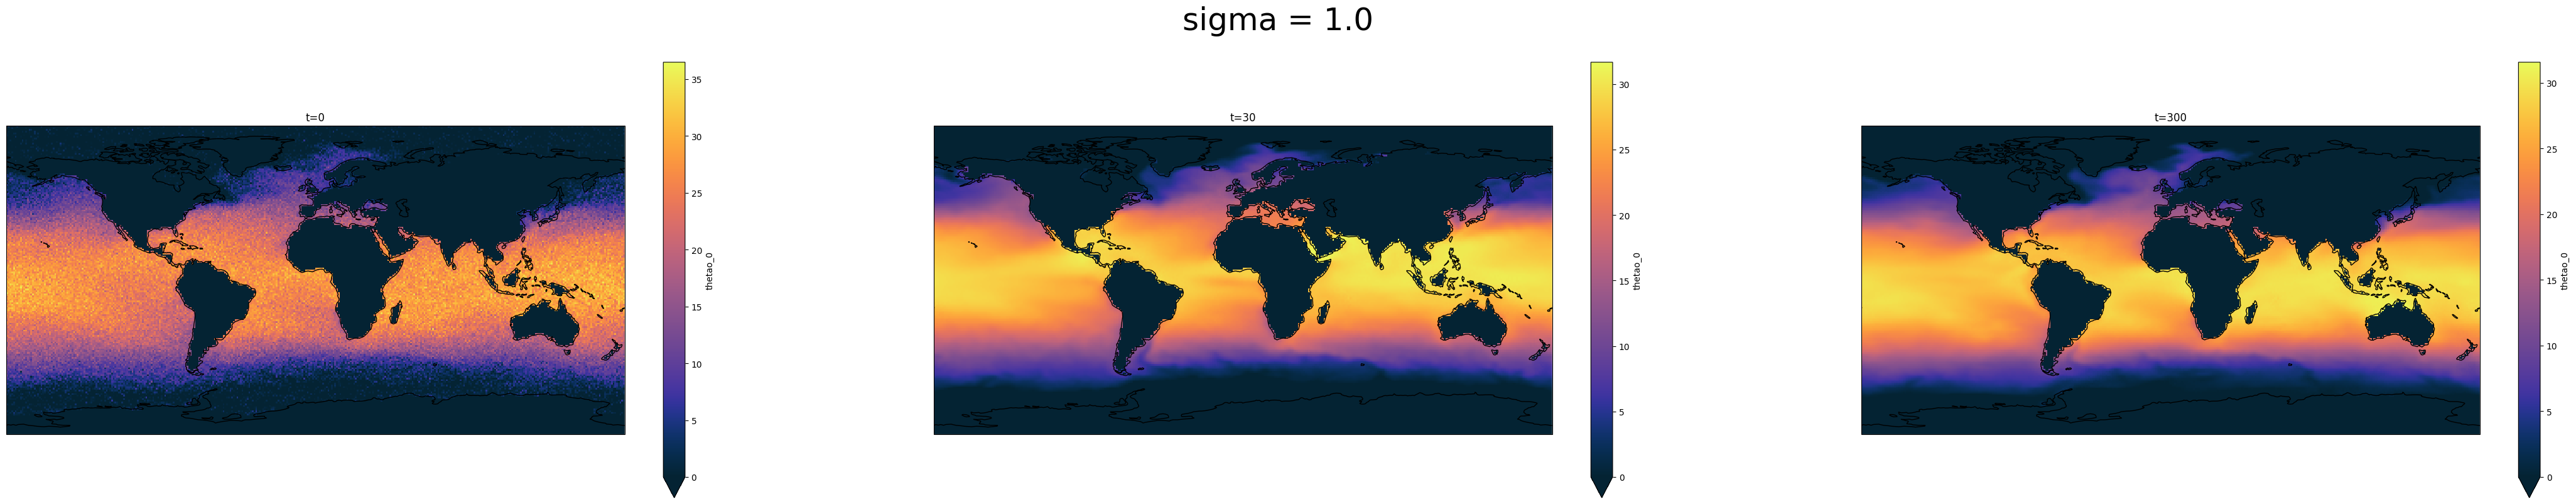

In [ ]:
timesteps = [0, 30, 300]

fig, axs = plt.subplots(
                nrows=1,
                ncols=len(timesteps),
                figsize=(18*len(timesteps),9),
                subplot_kw={
                    'projection': ccrs.PlateCarree(),
                    },
                )

for idx, timestep in enumerate(timesteps):
    member_ds.isel(time=timestep)["thetao_0"].plot(
        ax=axs[idx],
        transform=ccrs.PlateCarree(),
        cmap=cm.cm.thermal,
        vmin=0,
    )

    axs[idx].coastlines()
    axs[idx].set_title(f"t={timestep}")

fig.suptitle(f"sigma = {noise_level}", fontsize=36)

It would seem that a sigma of 1.0 is too much, while 0.5 is still stable.

**Note from Ronan:** the $\sigma$ that we're multiplying by 0.5 is very large for some variables due to it being calculated globally. For example, the SST varies between 0 and 30 accross the globe, so the standard deviation is around 10°C. It would be much more reasonable to use either a global value of the std. dev. **of the local anomaly** at each point.

### Ensemble variance analysis

We're making films of $\sigma_{SST}$ and $\sigma_{SSH}$ calculated accross ensemble members, and also of their mean to check for joint explosion.

In [14]:
noise_level = 1.0 # 0.5, 1.0, 2.0, 5.0

rollout_dir = Path(f"../Rollouts/Gaussian-10_member-Long/Long_ENS_OM4_thermo-sigma_{noise_level}")

ens_ds = xr.open_mfdataset(
    str(rollout_dir) + "/*/predictions.zarr",
    combine='nested', 
    concat_dim='member_idx',
    chunks=dict(time=1)
    ) * ocean_mask.where(ocean_mask)
ens_ds

/Odyssey/private/g22cossi/.miniforge3/envs/samudra/lib/python3.10/site-packages/xarray/backends/plugins.py:159: RuntimeWarning: 'scipy' fails while guessing
  warnings.warn(f"{engine!r} fails while guessing", RuntimeWarning)


<xarray.Dataset>
Dimensions:    (lat: 180, lon: 360, time: 1458, member_idx: 10)
Coordinates:
    areacello  (lat, lon) float64 1.699e+08 1.699e+08 ... 1.699e+08 1.699e+08
  * lat        (lat) float64 -89.24 -88.25 -87.25 -86.26 ... 87.25 88.25 89.24
  * lon        (lon) float64 0.5 1.5 2.5 3.5 4.5 ... 356.5 357.5 358.5 359.5
  * time       (time) int64 0 1 2 3 4 5 6 7 ... 282 283 284 285 286 287 288 289
Dimensions without coordinates: member_idx
Data variables: (12/39)
    so_0       (member_idx, time, lat, lon) float64 dask.array<chunksize=(1, 1, 180, 360), meta=np.ndarray>
    so_1       (member_idx, time, lat, lon) float64 dask.array<chunksize=(1, 1, 180, 360), meta=np.ndarray>
    so_10      (member_idx, time, lat, lon) float64 dask.array<chunksize=(1, 1, 180, 360), meta=np.ndarray>
    so_11      (member_idx, time, lat, lon) float64 dask.array<chunksize=(1, 1, 180, 360), meta=np.ndarray>
    so_12      (member_idx, time, lat, lon) float64 dask.array<chunksize=(1, 1, 180, 360), meta=np.ndarray>
    so_13      (member_idx, time, lat, lon) float64 dask.array<chunksize=(1, 1, 180, 360), meta=np.ndarray>
    ...         ...
    thetao_5   (member_idx, time, lat, lon) float64 dask.array<chunksize=(1, 1, 180, 360), meta=np.ndarray>
    thetao_6   (member_idx, time, lat, lon) float64 dask.array<chunksize=(1, 1, 180, 360), meta=np.ndarray>
    thetao_7   (member_idx, time, lat, lon) float64 dask.array<chunksize=(1, 1, 180, 360), meta=np.ndarray>
    thetao_8   (member_idx, time, lat, lon) float64 dask.array<chunksize=(1, 1, 180, 360), meta=np.ndarray>
    thetao_9   (member_idx, time, lat, lon) float64 dask.array<chunksize=(1, 1, 180, 360), meta=np.ndarray>
    zos        (member_idx, time, lat, lon) float64 dask.array<chunksize=(1, 1, 180, 360), meta=np.ndarray>

In [10]:
ens_std_ds = ens_ds.std(dim='member_idx')
ens_mean_ds = ens_ds.mean(dim='member_idx')

In [15]:
var_to_plot = "zos" # "thetao_0" or "zos" 
stat_to_plot = "mean" # "std" or "mean"

plt.rcParams['text.usetex'] = False

da = ens_std_ds[var_to_plot] if stat_to_plot == "std" else ens_mean_ds[var_to_plot]
zonal_da = da.mean(dim='lon')

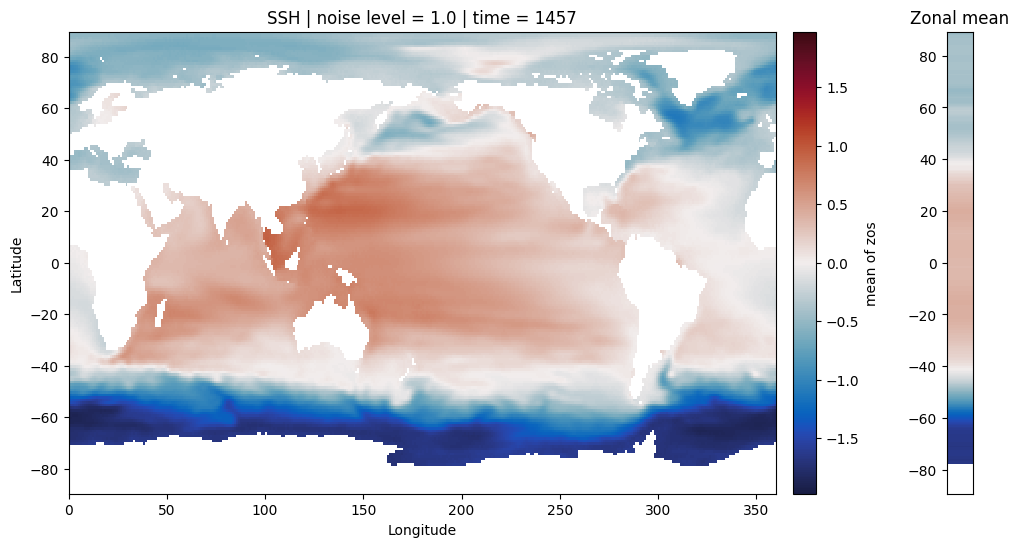

In [16]:
if stat_to_plot == "std":
    cmap = "viridis"
else:
    cmap = cm.cm.thermal if var_to_plot == "thetao_0" else cm.cm.balance

var_str = "SST" if var_to_plot == "thetao_0" else "SSH"

# Precompute color limits for consistent scaling
if stat_to_plot == "std" or var_to_plot == "thetao_0":
    vmin = 0
    vmax = float(da.max())
else:
    abs_max = float(abs(da).max())
    vmin = -abs_max
    vmax = abs_max
norm = plt.Normalize(vmin=vmin, vmax=vmax)

fig = plt.figure(figsize=(12, 6))
gs = fig.add_gridspec(1, 2, width_ratios=[11, 1], wspace=0)  # define the layout
ax1 = fig.add_subplot(gs[0, 0])  # first subplot
ax2 = fig.add_subplot(gs[0, 1])  # second subplot

# # Initial frame, map
t0 = 0
im_2Dmap = ax1.pcolormesh(
    ens_std_ds["lon"],
    ens_std_ds["lat"],
    da.isel(time=t0),
    shading="auto",
    cmap=cmap,
    norm=norm,
)

title = ax1.set_title(f"{var_str} | noise level = {noise_level} | time = {t0}")
ax1.set_xlabel("Longitude")
ax1.set_ylabel("Latitude")

cbar = fig.colorbar(im_2Dmap, ax=ax1, orientation="vertical", pad=0.02)
cbar_label = f"std. dev. of {var_to_plot}" if stat_to_plot == "std" else f"mean of {var_to_plot}"
cbar.set_label(cbar_label)

# Zonal mean 
im_zonal = ax2.imshow(
    zonal_da.isel(time=t0).values[:, None],
    aspect=0.1,
    origin="lower",
    extent=[0, 1, zonal_da.lat.min(), zonal_da.lat.max()],
    cmap=cmap,
    norm=norm,
)

ax2.set_title("Zonal mean")
ax2.tick_params(axis='x', which='both', bottom=False, top=False, labelbottom=False)

# # Animation update function
def update(frame):
    data = da.isel(time=frame)
    im_2Dmap.set_array(data.values.ravel())  # update pcolormesh data
    title.set_text(f"{var_str} | noise level = {noise_level} | time = {frame}")
    
    # Zonal mean
    im_zonal.set_data(zonal_da.isel(time=frame).values[:, None])

    return (im_2Dmap, im_zonal)


# Create animation
ani = animation.FuncAnimation(
    fig,
    update,
    frames=da.sizes["time"],
    interval=200,   # milliseconds between frames
    blit=False
)
ani.save(f"../Ensemble_figs/Long-{var_str}_sigma_{noise_level}_{stat_to_plot}.gif", writer="pillow", dpi=150)

plt.show()

### Analyzing if the ensemble spread stays consistent after stabilization

These figures show whether the perturbation is completely killed or if a small envelope forms around the ensemble

In [ ]:
noise_levels = [
    0.5,
    1.0,
    2.0,
    # 5.0,
]

# rollout_dirs = {noise_level: Path(f"../Rollouts/Gaussian-25_member/ENS_OM4_thermo-sigma_{noise_level}") for noise_level in noise_levels}
rollout_dirs = {noise_level: Path(f"../Rollouts/Gaussian-10_member-Long/Long_ENS_OM4_thermo-sigma_{noise_level}") for noise_level in noise_levels}

ens_ds_dict = {noise_level: xr.open_mfdataset(
                    str(rollout_dirs[noise_level]) + "/*/predictions.zarr",
                    chunks=dict(time=1),
                    combine='nested',
                    concat_dim='member_idx') * ocean_mask.where(ocean_mask)
                for noise_level in noise_levels}

/Odyssey/private/g22cossi/.miniforge3/envs/samudra/lib/python3.10/site-packages/xarray/backends/plugins.py:159: RuntimeWarning: 'scipy' fails while guessing
  warnings.warn(f"{engine!r} fails while guessing", RuntimeWarning)
/Odyssey/private/g22cossi/.miniforge3/envs/samudra/lib/python3.10/site-packages/xarray/backends/plugins.py:159: RuntimeWarning: 'scipy' fails while guessing
  warnings.warn(f"{engine!r} fails while guessing", RuntimeWarning)
/Odyssey/private/g22cossi/.miniforge3/envs/samudra/lib/python3.10/site-packages/xarray/backends/plugins.py:159: RuntimeWarning: 'scipy' fails while guessing
  warnings.warn(f"{engine!r} fails while guessing", RuntimeWarning)


/Odyssey/private/g22cossi/.miniforge3/envs/samudra/lib/python3.10/site-packages/dask/array/numpy_compat.py:53: RuntimeWarning: invalid value encountered in divide
  x = np.divide(x1, x2, out)


In [4]:
ens_std_ds_dict = {
    noise_level:
        ens_ds_dict[noise_level].std(dim='member_idx')
        for noise_level in noise_levels
        }

ens_mean_ds_dict = {
    noise_level:
        ens_ds_dict[noise_level].mean(dim='member_idx')
        for noise_level in noise_levels
        }

In [5]:
# Dictionary of std dev timeseries for each ensemble
ens_std_ts_dict= {
    noise_level:
        ens_std_ds_dict[noise_level].mean(dim=["lat", "lon"])
    for noise_level in noise_levels
    }

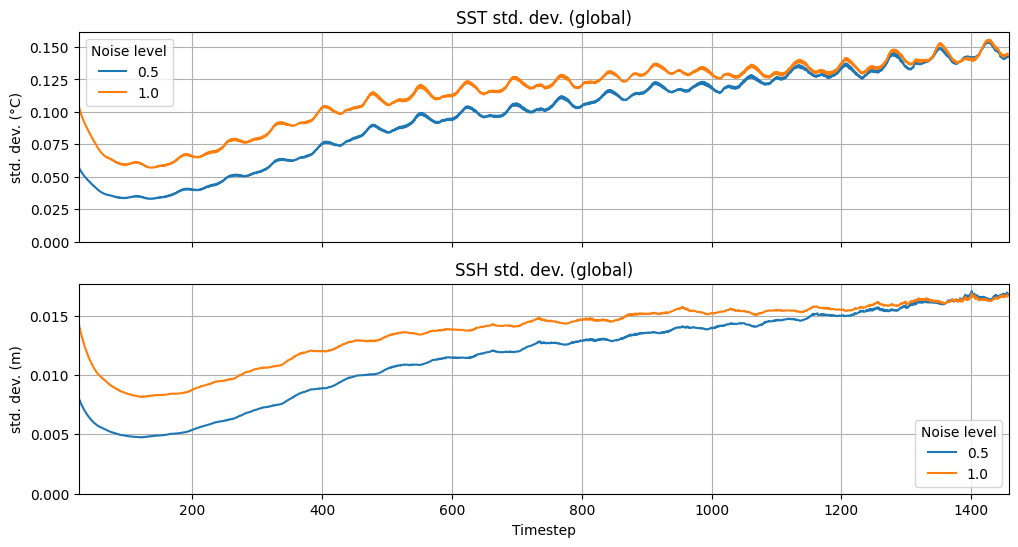

In [8]:
fig, (sst_ax, ssh_ax) = plt.subplots(2,1, sharex=True, figsize=(12, 6))

t0 = 25
tf = 1458
time_idxs = np.arange(t0, tf)

for noise_level in noise_levels:
    sst_ax.plot(
        time_idxs,
        ens_std_ts_dict[noise_level].thetao_0.isel(time=slice(t0, tf)),
        label=noise_level
    )
    ssh_ax.plot(
        time_idxs,
        ens_std_ts_dict[noise_level].zos.isel(time=slice(t0, tf)),
        label=noise_level
        )

sst_ax.set_title("SST std. dev. (global)")
sst_ax.legend(title="Noise level")
sst_ax.grid()
sst_ax.set_ylabel("std. dev. (°C)")
sst_ax.set_xlim(t0, tf)
sst_ax.set_ylim(bottom=0)

ssh_ax.set_title("SSH std. dev. (global)")
ssh_ax.set_xlabel("Timestep")
ssh_ax.legend(title="Noise level")
ssh_ax.grid()
ssh_ax.set_ylabel("std. dev. (m)")
ssh_ax.set_xlim(t0, tf)
ssh_ax.set_ylim(bottom=0);

# fig.savefig("../Ensemble_figs/std_timeseries.png")
fig.savefig("../Ensemble_figs/std_timeseries_long.png")

### Very long timeseries to check for stability

In [ ]:
noise_level = 1.0

rollout_dir = Path(f"../Rollouts/Very_long_ENS_OM4_thermo-sigma_{noise_level}")

ens_ds = xr.open_mfdataset(
    str(rollout_dir) + "/*/predictions.zarr",
    combine='nested', 
    concat_dim='member_idx',
    chunks=dict(time=1)
    ) * ocean_mask.where(ocean_mask)

ens_std_ds = ens_ds.std(dim='member_idx')
ens_mean_ds = ens_ds.mean(dim='member_idx')

/Odyssey/private/g22cossi/.miniforge3/envs/samudra/lib/python3.10/site-packages/xarray/backends/plugins.py:159: RuntimeWarning: 'scipy' fails while guessing
  warnings.warn(f"{engine!r} fails while guessing", RuntimeWarning)
/Odyssey/private/g22cossi/.miniforge3/envs/samudra/lib/python3.10/site-packages/xarray/backends/plugins.py:159: RuntimeWarning: 'scipy' fails while guessing
  warnings.warn(f"{engine!r} fails while guessing", RuntimeWarning)


<xarray.Dataset>
Dimensions:    (lat: 180, lon: 360, time: 2188)
Coordinates:
    areacello  (lat, lon) float64 1.699e+08 1.699e+08 ... 1.699e+08 1.699e+08
  * lat        (lat) float64 -89.24 -88.25 -87.25 -86.26 ... 87.25 88.25 89.24
  * lon        (lon) float64 0.5 1.5 2.5 3.5 4.5 ... 356.5 357.5 358.5 359.5
  * time       (time) int64 0 1 2 3 4 5 6 7 ... 136 137 138 139 140 141 142 143
Data variables: (12/39)
    so_0       (time, lat, lon) float64 dask.array<chunksize=(1, 180, 360), meta=np.ndarray>
    so_1       (time, lat, lon) float64 dask.array<chunksize=(1, 180, 360), meta=np.ndarray>
    so_10      (time, lat, lon) float64 dask.array<chunksize=(1, 180, 360), meta=np.ndarray>
    so_11      (time, lat, lon) float64 dask.array<chunksize=(1, 180, 360), meta=np.ndarray>
    so_12      (time, lat, lon) float64 dask.array<chunksize=(1, 180, 360), meta=np.ndarray>
    so_13      (time, lat, lon) float64 dask.array<chunksize=(1, 180, 360), meta=np.ndarray>
    ...         ...
    thetao_5   (time, lat, lon) float64 dask.array<chunksize=(1, 180, 360), meta=np.ndarray>
    thetao_6   (time, lat, lon) float64 dask.array<chunksize=(1, 180, 360), meta=np.ndarray>
    thetao_7   (time, lat, lon) float64 dask.array<chunksize=(1, 180, 360), meta=np.ndarray>
    thetao_8   (time, lat, lon) float64 dask.array<chunksize=(1, 180, 360), meta=np.ndarray>
    thetao_9   (time, lat, lon) float64 dask.array<chunksize=(1, 180, 360), meta=np.ndarray>
    zos        (time, lat, lon) float64 dask.array<chunksize=(1, 180, 360), meta=np.ndarray>

/Odyssey/private/g22cossi/.miniforge3/envs/samudra/lib/python3.10/site-packages/dask/array/numpy_compat.py:53: RuntimeWarning: invalid value encountered in divide
  x = np.divide(x1, x2, out)
/Odyssey/private/g22cossi/.miniforge3/envs/samudra/lib/python3.10/site-packages/dask/array/numpy_compat.py:53: RuntimeWarning: invalid value encountered in divide
  x = np.divide(x1, x2, out)
/Odyssey/private/g22cossi/.miniforge3/envs/samudra/lib/python3.10/site-packages/dask/array/numpy_compat.py:53: RuntimeWarning: invalid value encountered in divide
  x = np.divide(x1, x2, out)
/Odyssey/private/g22cossi/.miniforge3/envs/samudra/lib/python3.10/site-packages/dask/array/numpy_compat.py:53: RuntimeWarning: invalid value encountered in divide
  x = np.divide(x1, x2, out)


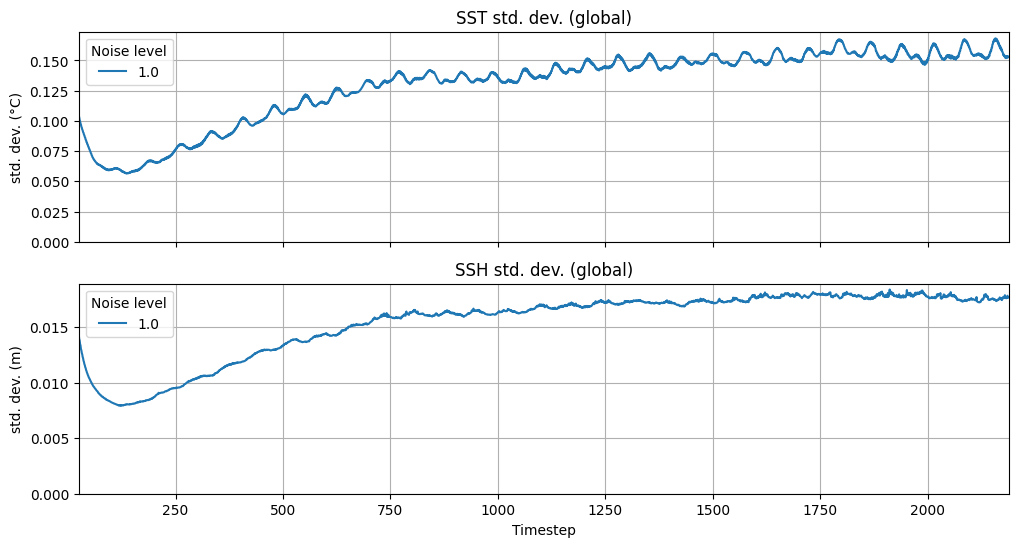

In [7]:
fig, (sst_ax, ssh_ax) = plt.subplots(2,1, sharex=True, figsize=(12, 6))

t0 = 25
tf = 2188
time_idxs = np.arange(t0, tf)

sst_ax.plot(
    time_idxs,
    ens_std_ds.thetao_0.isel(time=slice(t0, tf)).mean(dim=["lat", "lon"]),
    label=noise_level
)
ssh_ax.plot(
    time_idxs,
    ens_std_ds.zos.isel(time=slice(t0, tf)).mean(dim=["lat", "lon"]),
    label=noise_level
    )

sst_ax.set_title("SST std. dev. (global)")
sst_ax.legend(title="Noise level")
sst_ax.grid()
sst_ax.set_ylabel("std. dev. (°C)")
sst_ax.set_xlim(t0, tf)
sst_ax.set_ylim(bottom=0)

ssh_ax.set_title("SSH std. dev. (global)")
ssh_ax.set_xlabel("Timestep")
ssh_ax.legend(title="Noise level")
ssh_ax.grid()
ssh_ax.set_ylabel("std. dev. (m)")
ssh_ax.set_xlim(t0, tf)
ssh_ax.set_ylim(bottom=0);

fig.savefig("../Ensemble_figs/std_timeseries_very_long.png")